# MLP model-size experiment

Same MLP, same `3d` keypoints, same images - only `HIDDEN_LAYERS` changes.

**Nothing is trained here** - this only reads what `run.py` already saved. In
`config.py` set `EXPERIMENT_MODE = True` and `EXPERIMENT` to one of the `MLP_SIZES`
keys, then run one pass per size:

```bash
python run.py --cache
```

Each pass writes `experiments/<EXPERIMENT>/asl_mlp_<EXPERIMENT>_3d_runs.joblib`: every
iteration's loss history plus its `test_set` predictions. `EXPERIMENT_MODE` also forces
`FEATURES = "3d"` and keeps all output out of `neural_network/`, so a sweep can never
overwrite your deployable weights.

Six reports:

1. train / validation loss
2. train / validation accuracy
3. per-class precision, recall, F1 and accuracy on `test_set`
4. confusion matrix on `test_set`
5. average final accuracy vs model size
6. model architecture

Reports 1-4 and 6 show the **median iteration** of each size. `REPORT` in the next cell
chooses how many sizes they cover:

```python
REPORT = None          # all sizes, best accuracy first (default)
REPORT = "h256_128"    # just this one
```

Report 5 always covers every size.

24 static letters (`J`/`Z` excluded). Every score comes from `test_set/` alone.

**Kernel:** anything with `numpy`, `pandas`, `sklearn`, `matplotlib`, `joblib`.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
import config as cfg

# ---- knob ------------------------------------------------------------------- #
REPORT = None            # None = reports 1-4 and 6 for EVERY size, best first;
                         # or one MLP_SIZES key ("h256_128", ...) for just that one

# One <stem>_runs.joblib per size, written by `run.py --cache` with
# EXPERIMENT_MODE = True: train.py saves each iteration, test.py scores it on test_set.
res = {}
for f in sorted((ROOT / "experiments").glob("*/*_runs.joblib")):
    try:
        d = joblib.load(f)       # a size still mid-sweep holds pickled ASLClassifiers,
    except Exception:            # which need torch and neural_network/ on sys.path
        continue
    if "accuracy" in d:          # skip a size whose test.py stage never finished
        res[f.parent.name] = d
assert res, ("no scored experiments/*/*_runs.joblib -- run `python run.py --cache` "
             "with EXPERIMENT_MODE = True")


def n_params(d):
    """Trainable weights of a saved run, from ITS OWN recorded architecture."""
    n, prev = 0, d["dims"]
    for h in d["hidden_layers"]:
        n += prev * h + h + (2 * h if d["batch_norm"] else 0)
        prev = h
    return n + prev * d["n_classes"] + d["n_classes"]


for d in res.values():
    d["n_classes"] = len(set(d["y_true"]))
SIZES = sorted(res, key=lambda s: n_params(res[s]))      # smallest net first
print(f"{len(res)} sizes: {', '.join(SIZES)}")

15 sizes: h32, h64, h128, h128_64, h256, h512, h256_128, h256_128_64, h1024, h512_256, h512_256_128, h512_512_256, h1024_512, h1024_512_256, h1024_1024_512


In [2]:
first = res[SIZES[0]]
print(f"features: {first['features']} ({first['dims']} dims) | "
      f"test_set: {len(first['y_true'])} detected hands, {first['n_classes']} classes")

pd.DataFrame([{"hidden layers": str(tuple(res[s]["hidden_layers"])),
               "params": n_params(res[s]),
               "iterations": len(res[s]["accuracy"]),
               "mean test accuracy": round(float(np.mean(res[s]["accuracy"])), 4)}
              for s in SIZES], index=SIZES)

features: 3d (63 dims) | test_set: 905 detected hands, 24 classes


,hidden layers,params,iterations,mean test accuracy
h32,"(32,)",2904,5,0.7207
h64,"(64,)",5784,5,0.7414
h128,"(128,)",11544,5,0.7445
h128_64,"(128, 64)",18392,5,0.7607
h256,"(256,)",23064,5,0.7397
h512,"(512,)",46104,5,0.7328
h256_128,"(256, 128)",53144,5,0.7543
h256_128_64,"(256, 128, 64)",59992,5,0.7682
h1024,"(1024,)",92184,5,0.7401
h512_256,"(512, 256)",171800,5,0.7529


In [3]:
assert REPORT is None or REPORT in res, f"REPORT must be one of {SIZES}"
REPORTED = sorted(res, key=lambda s: -np.mean(res[s]["accuracy"])) if REPORT is None \
    else [REPORT]

# One run per size: the median iteration, so the reports show a typical run and not
# the luckiest one. (size -> iteration index, loss history, true labels, predictions)
SHOWN = {}
for s, d in res.items():
    it = int(np.argsort(d["accuracy"])[len(d["accuracy"]) // 2])
    SHOWN[s] = (it, d["histories"][it], d["y_true"], d["y_pred"][it])

print(f"reports 1-4 and 6 cover {len(REPORTED)} of {len(res)} sizes: "
      + ", ".join(f"{s} (median iteration {SHOWN[s][0]})" for s in REPORTED))

reports 1-4 and 6 cover 15 of 15 sizes: h512_256_128 (median iteration 2), h512_512_256 (median iteration 1), h256_128_64 (median iteration 0), h128_64 (median iteration 3), h1024_512 (median iteration 4), h1024_1024_512 (median iteration 0), h1024_512_256 (median iteration 4), h256_128 (median iteration 3), h512_256 (median iteration 4), h128 (median iteration 0), h64 (median iteration 1), h1024 (median iteration 4), h256 (median iteration 1), h512 (median iteration 2), h32 (median iteration 0)


## 1. Train / validation loss

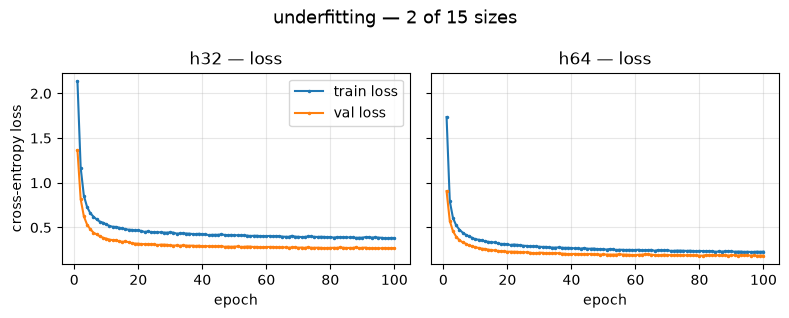

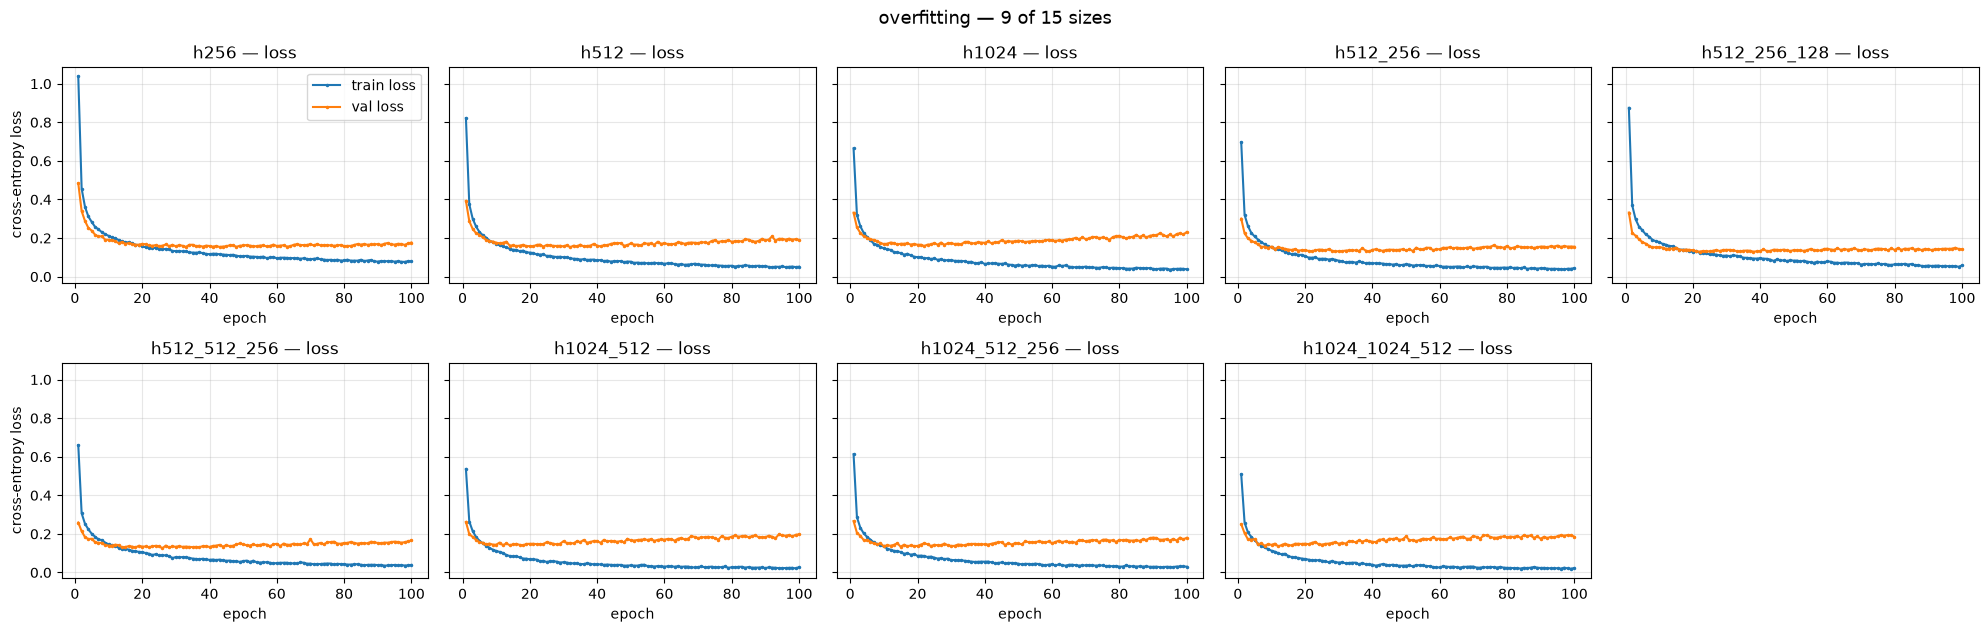

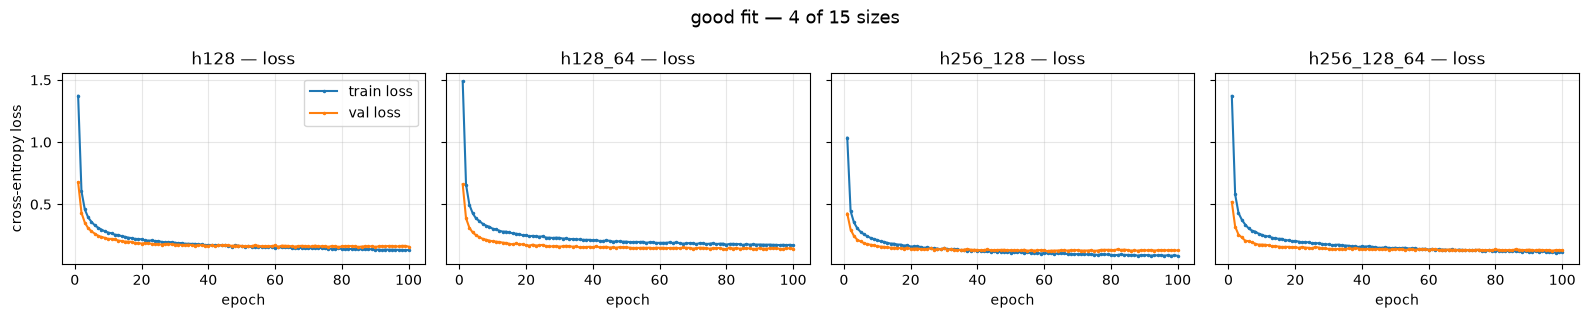

underfitting  h32             final train 0.3822   val 0.2691
underfitting  h64             final train 0.2302   val 0.1859
good fit      h128            final train 0.1316   val 0.1592
good fit      h128_64         final train 0.1700   val 0.1440
overfitting   h256            final train 0.0791   val 0.1769
overfitting   h512            final train 0.0516   val 0.1907
good fit      h256_128        final train 0.0858   val 0.1284
good fit      h256_128_64     final train 0.1182   val 0.1314
overfitting   h1024           final train 0.0381   val 0.2313
overfitting   h512_256        final train 0.0444   val 0.1552
overfitting   h512_256_128    final train 0.0580   val 0.1419
overfitting   h512_512_256    final train 0.0393   val 0.1659
overfitting   h1024_512       final train 0.0279   val 0.1975
overfitting   h1024_512_256   final train 0.0303   val 0.1798
overfitting   h1024_1024_512  final train 0.0231   val 0.1852


In [11]:
# One figure per regime, first match wins, so every size lands in exactly one.
REGIMES = {"underfitting": lambda s: s in ("h32", "h64"),
           "overfitting":  lambda s: "512" in s or "1024" in s or s == "h256",
           "good fit":     lambda s: True}


def regime_of(size):
    return next(r for r, keep in REGIMES.items() if keep(size))


shown = [s for s in SIZES if s in REPORTED]     # smallest net first inside a regime

# Each figure scales to its own regime (sharey): a common range across all three would
# be set by h32's epoch-1 spike, flattening the train/val gap that is the whole point.
for regime in REGIMES:
    members = [s for s in shown if regime_of(s) == regime]
    if not members:
        continue
    ncols = min(5, len(members))
    nrows = -(-len(members) // ncols)           # ceil: wrap onto more rows
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                             sharey=True, squeeze=False)
    for k, (ax, size) in enumerate(zip(axes.flat, members)):
        _, h, _, _ = SHOWN[size]
        ax.plot(range(1, len(h["loss"]) + 1), h["loss"], marker=".", ms=3,
                label="train loss")
        ax.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], marker=".", ms=3,
                label="val loss")
        ax.set_xlabel("epoch")
        ax.set_title(f"{size} \u2014 loss")
        ax.grid(alpha=0.3)
        if k % ncols == 0:
            ax.set_ylabel("cross-entropy loss")
        if k == 0:
            ax.legend()
    for ax in axes.flat[len(members):]:         # blank any leftover panel
        ax.axis("off")
    fig.suptitle(f"{regime} \u2014 {len(members)} of {len(shown)} sizes", fontsize=13)
    fig.tight_layout()
    plt.show()

for size in shown:
    _, h, _, _ = SHOWN[size]
    print(f"{regime_of(size):<13} {size:<15} final train {h['loss'][-1]:.4f}   "
          f"val {h['val_loss'][-1]:.4f}")

## 2. Train / validation accuracy

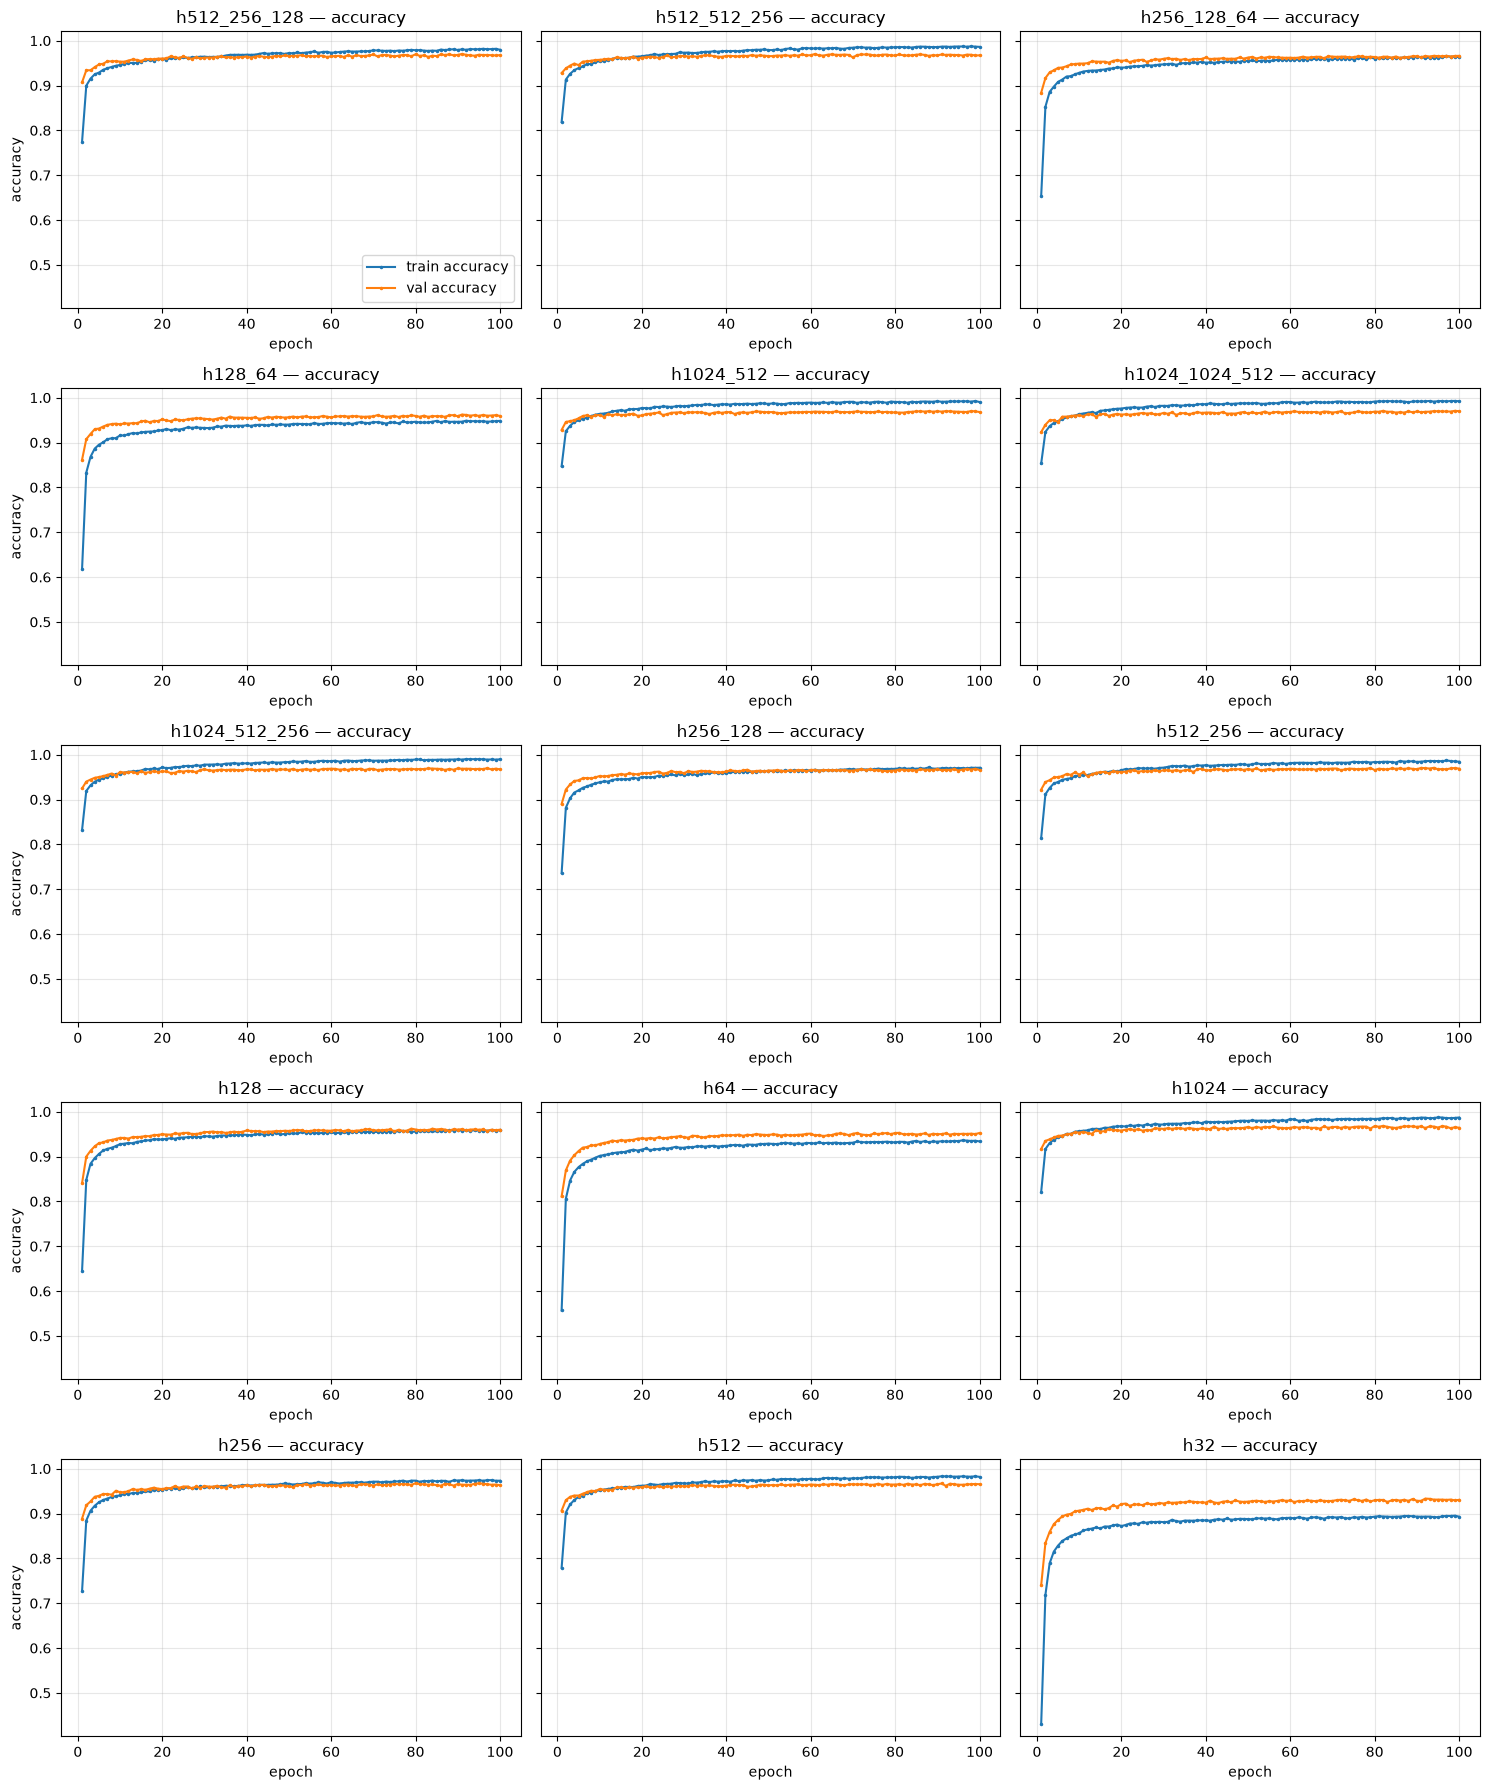

h512_256_128: final train 0.9798   val 0.9677
h512_512_256: final train 0.9861   val 0.9673
h256_128_64: final train 0.9634   val 0.9660
h128_64: final train 0.9482   val 0.9593
h1024_512: final train 0.9902   val 0.9680
h1024_1024_512: final train 0.9920   val 0.9697
h1024_512_256: final train 0.9895   val 0.9672
h256_128: final train 0.9709   val 0.9658
h512_256: final train 0.9844   val 0.9688
h128: final train 0.9585   val 0.9597
h64: final train 0.9336   val 0.9524
h1024: final train 0.9869   val 0.9641
h256: final train 0.9731   val 0.9631
h512: final train 0.9817   val 0.9653
h32: final train 0.8929   val 0.9304


In [5]:
ncols = min(5, len(REPORTED))                   # 5 wide: the 15 sizes land as 3 x 5
nrows = -(-len(REPORTED) // ncols)              # ceil: wrap onto more rows
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                         sharey=True, squeeze=False)
for k, (ax, size) in enumerate(zip(axes.flat, REPORTED)):
    _, h, _, _ = SHOWN[size]
    ax.plot(range(1, len(h["accuracy"]) + 1), h["accuracy"], marker=".", ms=3,
            label="train accuracy")
    ax.plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], marker=".", ms=3,
            label="val accuracy")
    ax.set_xlabel("epoch")
    ax.set_title(f"{size} \u2014 accuracy")
    ax.grid(alpha=0.3)
    if k % ncols == 0:
        ax.set_ylabel("accuracy")
    if k == 0:
        ax.legend(loc="lower right")
for ax in axes.flat[len(REPORTED):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

for size in REPORTED:
    _, h, _, _ = SHOWN[size]
    print(f"{size}: final train {h['accuracy'][-1]:.4f}   "
          f"val {h['val_accuracy'][-1]:.4f}")

## 3. Per-class precision / recall / F1 on `test_set`

In [6]:
for size in REPORTED:
    it, _, yt, yp = SHOWN[size]
    labels = sorted(set(yt))
    rep = classification_report(yt, yp, labels=labels, zero_division=0,
                                output_dict=True)

    print(f"{size} on test_set \u2014 accuracy {accuracy_score(yt, yp):.4f} "
          f"({len(yt)} samples, iteration {it})")
    display(pd.DataFrame(
        {c: {"precision": rep[c]["precision"], "recall": rep[c]["recall"],
             "f1-score": rep[c]["f1-score"], "support": int(rep[c]["support"])}
         for c in labels}).T.round(3))

h512_256_128 on test_set — accuracy 0.7713 (905 samples, iteration 2)


,precision,recall,f1-score,support
A,0.508,0.886,0.646,35.0
B,0.970,0.865,0.914,37.0
C,0.900,0.973,0.935,37.0
D,0.451,0.622,0.523,37.0
E,0.714,0.769,0.741,39.0
F,0.969,0.795,0.873,39.0
G,0.761,0.875,0.814,40.0
H,0.864,0.950,0.905,40.0
I,0.944,0.872,0.907,39.0
K,0.861,0.775,0.816,40.0


h512_512_256 on test_set — accuracy 0.7702 (905 samples, iteration 1)


,precision,recall,f1-score,support
A,0.500,0.886,0.639,35.0
B,0.941,0.865,0.901,37.0
C,0.854,0.946,0.897,37.0
D,0.500,0.649,0.565,37.0
E,0.689,0.795,0.738,39.0
F,1.000,0.769,0.870,39.0
G,0.864,0.950,0.905,40.0
H,0.848,0.975,0.907,40.0
I,0.943,0.846,0.892,39.0
K,0.925,0.925,0.925,40.0


h256_128_64 on test_set — accuracy 0.7624 (905 samples, iteration 0)


...

,precision,recall,f1-score,support
A,0.484,0.857,0.619,35.0
B,0.969,0.838,0.899,37.0
C,0.773,0.919,0.840,37.0
D,0.543,0.514,0.528,37.0
E,0.633,0.795,0.705,39.0
F,0.966,0.718,0.824,39.0
G,0.787,0.925,0.851,40.0
H,0.860,0.925,0.892,40.0
I,0.829,0.872,0.850,39.0
K,0.895,0.850,0.872,40.0


h512 on test_set — accuracy 0.7304 (905 samples, iteration 2)


,precision,recall,f1-score,support
A,0.449,0.886,0.596,35.0
B,1.000,0.838,0.912,37.0
C,0.919,0.919,0.919,37.0
D,0.432,0.514,0.469,37.0
E,0.646,0.795,0.713,39.0
F,0.970,0.821,0.889,39.0
G,0.787,0.925,0.851,40.0
H,0.745,0.950,0.835,40.0
I,0.865,0.821,0.842,39.0
K,0.900,0.450,0.600,40.0


h32 on test_set — accuracy 0.7182 (905 samples, iteration 0)


,precision,recall,f1-score,support
A,0.500,0.886,0.639,35.0
B,0.969,0.838,0.899,37.0
C,0.872,0.919,0.895,37.0
D,0.553,0.568,0.560,37.0
E,0.705,0.795,0.747,39.0
F,0.846,0.846,0.846,39.0
G,0.635,0.825,0.717,40.0
H,0.593,0.875,0.707,40.0
I,0.921,0.897,0.909,39.0
K,0.850,0.425,0.567,40.0


## 4. Confusion matrix on `test_set`

In [ ]:
for size in REPORTED:
    it, _, yt, yp = SHOWN[size]
    fig, ax = plt.subplots(figsize=(11, 11))
    ConfusionMatrixDisplay.from_predictions(
        yt, yp, labels=sorted(set(yt)), ax=ax,
        colorbar=False, xticks_rotation="vertical", values_format="d")
    ax.set_title(f"{size} \u2014 test_set (iteration {it})")
    fig.tight_layout()
    plt.show()

## 5. Average final accuracy vs model size

Final accuracy of each size, averaged over its `ITERATIONS` runs. Sizes run
smallest-first, so a plateau (or a turn downward) is where extra capacity stops paying.

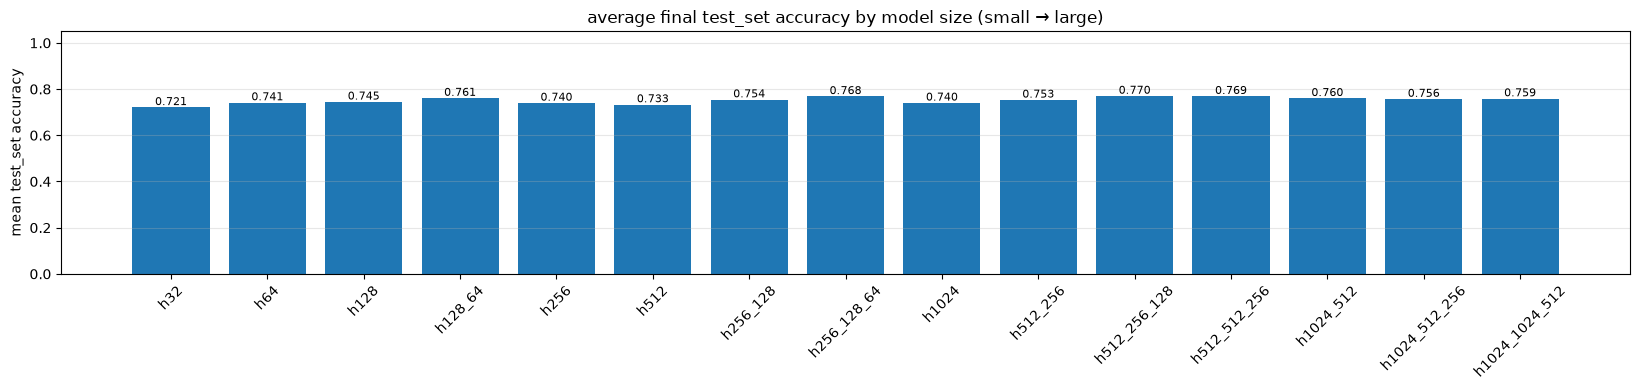

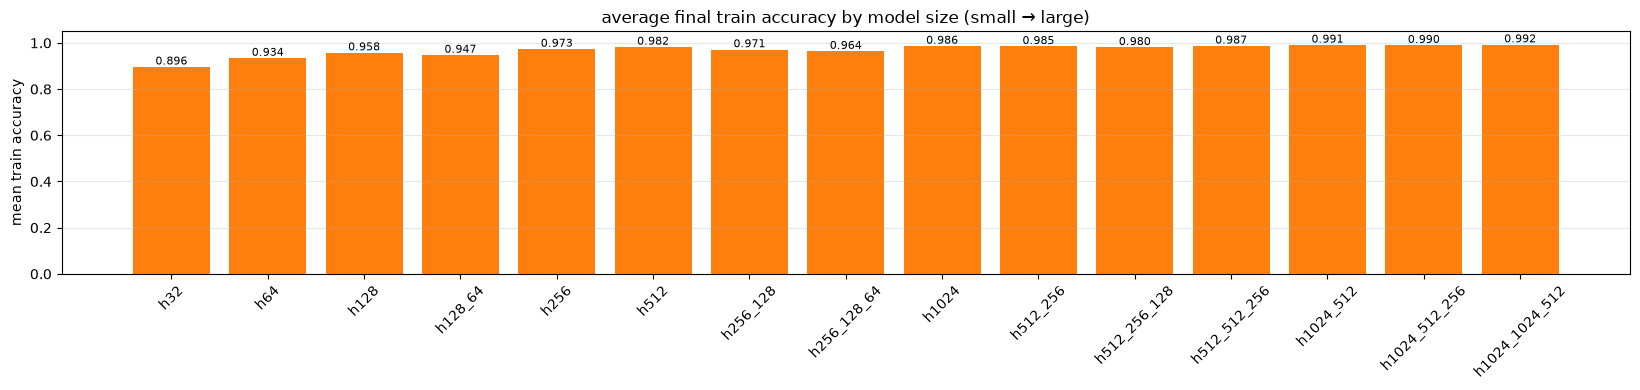

,params,mean test_set accuracy,mean train accuracy
h32,2904,0.7207,0.8962
h64,5784,0.7414,0.9339
h128,11544,0.7445,0.9577
h128_64,18392,0.7607,0.9473
h256,23064,0.7397,0.9734
h512,46104,0.7328,0.9823
h256_128,53144,0.7543,0.9710
h256_128_64,59992,0.7682,0.9639
h1024,92184,0.7401,0.9863
h512_256,171800,0.7529,0.9850


In [8]:
avg = pd.Series({s: np.mean(res[s]["accuracy"]) for s in SIZES})
avg_train = pd.Series({s: np.mean([h["accuracy"][-1] for h in res[s]["histories"]])
                       for s in SIZES})

for series, name, col in ((avg, "test_set", "C0"), (avg_train, "train", "C1")):
    fig, ax = plt.subplots(figsize=(max(7.5, 1.1 * len(SIZES)), 4))
    ax.bar(series.index, series.values, color=col)
    for k, v in enumerate(series):
        ax.text(k, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_ylabel(f"mean {name} accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"average final {name} accuracy by model size (small \u2192 large)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

pd.DataFrame({"params": [n_params(res[s]) for s in SIZES],
              "mean test_set accuracy": avg.round(4),
              "mean train accuracy": avg_train.round(4)})

## 6. Model architecture

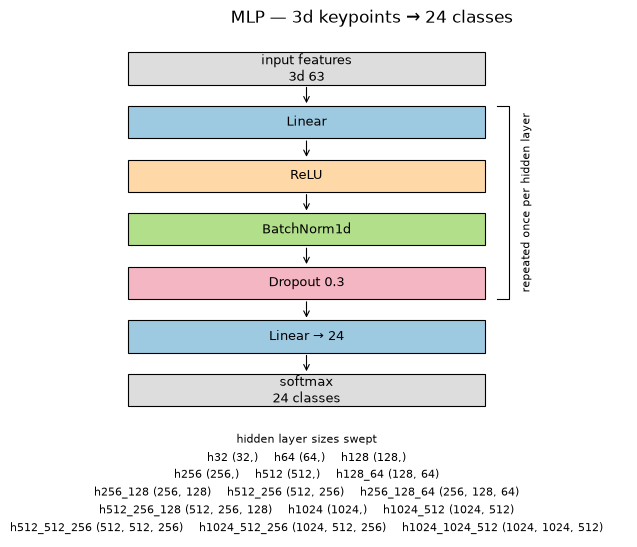

Adam lr 0.001 | cross-entropy loss | 100 epochs | batch 256 | seeded 20% validation split


In [9]:
# Size is the ONLY thing this sweep varies, so the net is drawn once and generically:
# the hidden block (its layer types, from a run's own record) plus every size in the
# grid annotated underneath. Per-size widths and parameter counts are in report 5.
d = res[SIZES[0]]
grid = [f"{k} {tuple(v)}" for k, v in cfg.MLP_SIZES.items()]
rows = ["    ".join(grid[i:i + 3]) for i in range(0, len(grid), 3)]

boxes = [(f"input features\n{d['features']} {d['dims']}", "io"),
         ("Linear", "lin"), ("ReLU", "act")]
if d["batch_norm"]:
    boxes.append(("BatchNorm1d", "bn"))
if d["dropout"] > 0:
    boxes.append((f"Dropout {d['dropout']}", "drop"))
hidden = (1, len(boxes) - 1)                    # first/last box of the repeated block
boxes += [(f"Linear \u2192 {d['n_classes']}", "lin"),
          (f"softmax\n{d['n_classes']} classes", "io")]

colour = {"io": "#dddddd", "lin": "#9ecae1", "act": "#ffd8a8",
          "bn": "#b2df8a", "drop": "#f4b6c2"}
foot = -0.45 - 0.34 * len(rows)                 # room under the boxes for the grid
fig, ax = plt.subplots(figsize=(6.5, 0.62 * len(boxes) - 0.62 * foot))
for k, (name, kind) in enumerate(boxes):
    y = len(boxes) - 1 - k                      # first box at the top
    ax.add_patch(plt.Rectangle((0, y), 3, 0.6, facecolor=colour[kind],
                               edgecolor="black", lw=0.8))
    ax.text(1.5, y + 0.3, name, ha="center", va="center",
            fontsize=8 if len(name) > 28 else 9)
    if k:                                       # arrow down from the box above
        ax.annotate("", xy=(1.5, y + 0.6), xytext=(1.5, y + 1.0),
                    arrowprops=dict(arrowstyle="->", lw=0.8))

# brace over the repeated hidden block
lo, hi = len(boxes) - 1 - hidden[1], len(boxes) - 1 - hidden[0] + 0.6
ax.plot([3.1, 3.2, 3.2, 3.1], [lo, lo, hi, hi], color="black", lw=0.8)
ax.text(3.3, (lo + hi) / 2, "repeated once per hidden layer",
        rotation=90, ha="left", va="center", fontsize=8)

ax.text(1.5, foot + 0.34 * len(rows), "hidden layer sizes swept\n" + "\n".join(rows),
        ha="center", va="top", fontsize=8, linespacing=1.6)
ax.set_xlim(-0.1, 4.2)
ax.set_ylim(foot, len(boxes))
ax.axis("off")
ax.set_title(f"MLP \u2014 {d['features']} keypoints \u2192 {d['n_classes']} classes")
fig.tight_layout()
plt.show()

print("Adam lr", cfg.LEARNING_RATE, "| cross-entropy loss |", cfg.EPOCHS, "epochs |",
      f"batch {cfg.BATCH_SIZE} | seeded {cfg.VAL_SPLIT:.0%} validation split")